In [23]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.preprocessing import StandardScaler

sys.path.append("../scripts")

from aggl_clustering_pipeline import cluster_breast_cancer_target_vs_rest
from utils import make_pseudobulk

# Breast cancer subtype classification

This notebook compares two approaches of donor-level breast cancer subtype classification.

The most common method is PAM50 classification with `genefu`. However, its reference centroids were derived from microarray data [LINK], which makes them suboptimal for RNA-seq pseudobulk expression profiles.

As an alternative, I use published gene panels from a classifier based on a sequence of binary boosted trees [LINK]. The original model is not available, so these genes are used here to build a custom subtype assignment workflow based on sequential hierarchical clustering.

The analysis proceeds from tumor-cell pseudobulks and produces subtype labels with both methods for comparison.

## Load data

In [2]:
adata = sc.read_h5ad('../data/7cdea341-ca7a-40fd-8192-b8ecb2d7b91e.h5ad')
adata

AnnData object with n_obs × n_vars = 621200 × 37389
    obs: 'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'grade', 'author_cell_type', 'batch', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'batch_condition', 'citation', 'default_embedding', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title'
    obsm: 'X_rpca', 'X_umap'

## Construct tumor pseudobulks

PAM50 classification is based on the expression patterns of 50 key genes in tumor cells. For this reason, the analysis uses pseudobulk profiles constructed from malignant cells only.

In [3]:
mask_tumor = adata.obs['cell_type'] == 'malignant cell'
adata_tumor = adata[mask_tumor].copy()

print('Tumor cells:', adata_tumor.n_obs)
print('Donors total:', adata.obs['donor_id'].nunique())
print('Donors with tumor cells:', adata_tumor.obs['donor_id'].nunique())

Tumor cells: 242613
Donors total: 138
Donors with tumor cells: 136


Two donors have no detected tumor cells.

To obtain stable donor-level profiles, only donors with at least 50 malignant cells are kept. This removes very small tumor-cell groups that would produce unreliable pseudobulks.

In [4]:
min_tumor_cells = 50
tumor_cells_per_donor = adata_tumor.obs['donor_id'].value_counts()

keep_donors = tumor_cells_per_donor.index[tumor_cells_per_donor >= min_tumor_cells]
adata_tumor_filt = adata_tumor[adata_tumor.obs['donor_id'].isin(keep_donors)].copy()

print('Tumor cells (before):', adata_tumor.n_obs)
print('Tumor cells (after):', adata_tumor_filt.n_obs)
print('Donors (before):', adata_tumor.obs['donor_id'].nunique())
print('Donors (after):', adata_tumor_filt.obs['donor_id'].nunique())

Tumor cells (before): 242613
Tumor cells (after): 242434
Donors (before): 136
Donors (after): 125


The count matrix is indexed by Ensembl gene IDs, while subtype classifiers use HGNC gene symbols.

Keep the mapping between Ensembl IDs and gene names for for further analysis:

In [5]:
gene_id = adata_tumor_filt.var_names.astype(str)
hgnc = adata_tumor_filt.var['feature_name'].astype(str)
id_to_symbol = dict(zip(gene_id, hgnc))

After filtering, pseudobulks are generated by aggregating raw counts across malignant cells for each donor:

In [6]:
pb_tumor_df, meta_tumor = make_pseudobulk(
    adata=adata_tumor_filt,
    donor_col='donor_id',
    group_col='cell_type',
    min_cells=50,
    return_pb=True,
    save=True,
    out_dir='../data/pseudobulks_tumor',
    counts_name='pseudobulks_tumor_counts_gene_by_sample.tsv',
    meta_name='pseudobulks_tumor_sample_metadata.tsv')

## Normalize pseudobulk expression

For donor-level comparison, pseudobulk counts are normalized with TMM and transformed to logCPM using `edgeR`.

TMM (Trimmed Mean of M-values) adjusts for differences in library size and composition bias across donors.

The resulting logCPM (log Counts Per Million) matrix is used for downstream exploratory analysis and subtype classification.

In [7]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

ro.r('source("../scripts/tmm_logcpm_pam50_subtyping.R")')

with localconverter(pandas2ri.converter):
     ro.r('pb_tumor_logcpm_df <- tmm_logcpm_tsv("../data/pseudobulks_tumor/pseudobulks_tumor_counts_gene_by_sample.tsv", '
          '"../data/pseudobulks_tumor/pseudobulks_tumor_counts_gene_by_sample_logcpm.tsv", '
          'prior_count=1.0)')
     pb_tumor_logcpm_df = ro.globalenv['pb_tumor_logcpm_df']

[tmm_logcpm_tsv] reading: ../data/pseudobulks_tumor/pseudobulks_tumor_counts_gene_by_sample.tsv 
[tmm_logcpm_tsv] running edgeR DGEList + TMM + cpm(log=TRUE)
[tmm_logcpm_tsv] writing: ../data/pseudobulks_tumor/pseudobulks_tumor_counts_gene_by_sample_logcpm.tsv 
[tmm_logcpm_tsv] done in sec: 24.07 


## PAM50 subtype assignment with `genefu`

The subtype classification is assigned based on the nearest of the five centroids. 
> Because of its reproducibility in subtype classification, the final algorithm consisted of centroids constructed as described for the PAM algorithm (link above) and distances calculated using Spearman's rank correlation.
https://pmc.ncbi.nlm.nih.gov/articles/PMC2667820/


Select [PAM50 genes](https://genome-publications.bioinf.unc.edu/PAM50/PAM50_R/pam50_annotation.txt):

In [8]:
pam50_gene_set = {'ACTR3B', 'ANLN', 'BAG1', 'BCL2', 'BIRC5', 'BLVRA', 'CCNB1', 'CCNE1', 'CDC20', 'CDC6',
                  'NUF2', 'CDH3', 'CENPF', 'CEP55', 'CXXC5', 'EGFR', 'ERBB2', 'ESR1', 'EXO1', 'FGFR4', 
                  'FOXA1', 'FOXC1', 'GPR160', 'GRB7', 'KIF2C', 'NDC80', 'KRT14', 'KRT17', 'KRT5', 'MAPT', 
                  'MDM2', 'MELK', 'MIA', 'MKI67', 'MLPH', 'MMP11', 'MYBL2', 'MYC', 'NAT1', 'ORC6', 
                  'PGR', 'PHGDH', 'PTTG1', 'RRM2', 'SFRP1', 'SLC39A6', 'TMEM45B', 'TYMS', 'UBE2C', 'UBE2T'}

Check that all genes are in the data:

In [9]:
pb_gene_meta = pd.DataFrame({
    'gene_id': pb_tumor_df.columns.astype(str),
})
pb_gene_meta['symbol'] = pb_gene_meta['gene_id'].map(id_to_symbol)

common = pam50_gene_set & set(pb_gene_meta['symbol'])
print('Common PAM50 genes:', len(common))

Common PAM50 genes: 50


Filter normalized pseudobulks and assign HGNC names:

In [10]:
mask_pam50 = pb_gene_meta['symbol'].isin(pam50_gene_set).values

df_pam50 = pb_tumor_logcpm_df.loc[:, mask_pam50] # donors x PAM50 gene_id
df_pam50.columns = pb_gene_meta.loc[mask_pam50, 'symbol'].tolist()

print('Selected columns:', df_pam50.shape[1])
display(df_pam50.iloc[:3, :10])

Selected columns: 50


,CDC20,KIF2C,PHGDH,NUF2,UBE2T,CENPF,EXO1,RRM2,MLPH,GPR160
BC17086-12_Tumor__malignant cell,5.213013,3.740069,6.856400,4.928237,6.465107,6.174144,3.740069,6.368974,3.257817,1.952444
BC17086-24_Tumor__malignant cell,6.804095,4.220174,5.225654,4.526986,7.319403,8.066382,3.472140,5.156167,3.826335,1.505131
BC17086-35_Tumor__malignant cell,5.210445,2.967993,7.096826,3.927407,5.643961,4.779892,-0.176684,4.876011,7.576456,6.506543


Run `genefu`:

In [11]:
import rpy2.robjects as ro
from rpy2.robjects import pandas2ri
from rpy2.robjects.conversion import localconverter

ro.r('source("../scripts/tmm_logcpm_pam50_subtyping.R")')

with localconverter(pandas2ri.converter):
    expr_df = pandas2ri.py2rpy(df_pam50)
    ro.globalenv['expr_df'] = expr_df
    ro.r('subtype_genefu <- pam50_genefu_subtyping(expr_df)')
    subtype_genefu = ro.globalenv['subtype_genefu']

subtype_genefu.head(3)

,subtype
BC17086-12_Tumor__malignant cell,Basal
BC17086-24_Tumor__malignant cell,Basal
BC17086-35_Tumor__malignant cell,ERBB2


Create `genefu` labels:

In [12]:
y_subtype_genefu = subtype_genefu.iloc[:, 0].astype('string')
y_subtype_genefu.head(3)

BC17086-12_Tumor__malignant cell    Basal
BC17086-24_Tumor__malignant cell    Basal
BC17086-35_Tumor__malignant cell    ERBB2
Name: subtype, dtype: string

## Sequential binary clustering

There is described a hierarchical clustering approach inspired by the BostonGene study: https://doi.org/10.1038/s41523-025-00723-0

Instead of pathway signatures, this analysis uses node-specific discriminative gene panels derived from the decision trees in that study.

The strategy is sequential:
1. separate Basal-like tumors from the rest;
2. within the remaining samples, separate ERBB2+ tumors;
3. within the remaining luminal samples, separate LumB from LumA.

This produces a four-class solution: `Basal`, `ERBB2`, `LumA`, `LumB`. 

Normal-like type is excluded here.

### Filter pseudobulks by genes

Gene panels for clustering:

In [13]:
basal_gene_set = {'CCNE1', 'ANLN', 'TWIST1', 'NUF2', 'ERBB2', 'MAPT', 'MLPH', 'SOX10', 'PHGDH', 'AR',
                  'GPR160', 'ESR1', 'TFAP2B', 'CDC6', 'GRB7', 'ELF5', 'CDC20', 'FOXA1', 'FOXC1', 'PGR'}

erbb2_gene_set = {'ACTR3B', 'LBP', 'CCNE1', 'BAG1', 'BCL2', 'ANLN', 'NUF2', 'ERBB2', 'CDH3', 'MAPT',
                  'MLPH', 'PPARG', 'MDM2', 'MKI67', 'GPR160', 'ESR1', 'FABP7', 'WNK4', 'CDC6',
                  'VIM', 'GRB7', 'UBE2T', 'MMP11', 'CDC20', 'KRT5', 'CTNNA1', 'KRT17'}

luma_lumb_prolif_gene_set = {'CCNB1', 'AURKB', 'AURKA', 'PLK1', 'MCM2', 'BUB1', 'E2F1', 'MKI67', 'MYBL2'}
luma_lumb_anti_prolif_gene_set = {'GNG12', 'SOCS5', 'CRY2', 'ELN', 'PTPN21', 'COL14A1', 'ZNF608', 'ZCCHC24', 'AASS'}
luma_lumb_union_gene_set = luma_lumb_prolif_gene_set | luma_lumb_anti_prolif_gene_set

Check that all genes are in the data:

In [14]:
bg_gene_set = set().union(
    basal_gene_set,
    erbb2_gene_set,
    luma_lumb_union_gene_set 
)
common = sorted(set(bg_gene_set).intersection(pb_gene_meta['symbol']))
print('Total BG genes:', len(bg_gene_set))
print('Common BG genes:', len(common))

Total BG genes: 53
Common BG genes: 53


Filter normalized pseudobulks and assign HGNC names:

In [15]:
mask_bg_genes = pb_gene_meta['symbol'].isin(bg_gene_set).values
df_bg_genes = pb_tumor_logcpm_df.loc[:, mask_bg_genes] # donors x PAM50 gene_id
df_bg_genes.columns = pb_gene_meta.loc[mask_bg_genes, 'symbol'].tolist()

print('Selected columns:', df_bg_genes.shape[1])
display(df_bg_genes.iloc[:3, :10])

Selected columns: 53


,CDC20,GNG12,PHGDH,NUF2,UBE2T,SOCS5,BUB1,MLPH,PPARG,MCM2
BC17086-12_Tumor__malignant cell,5.213013,4.786579,6.856400,4.928237,6.465107,-3.764228,4.389253,3.257817,-3.764228,5.992503
BC17086-24_Tumor__malignant cell,6.804095,4.327278,5.225654,4.526986,7.319403,-2.463392,3.952155,3.826335,0.725561,4.968712
BC17086-35_Tumor__malignant cell,5.210445,6.047370,7.096826,3.927407,5.643961,-2.610676,1.806696,7.576456,1.948192,2.753381


### Standardize expression for clustering

Before clustering, expression values are standardized gene-wise across donors using z-scores. This makes genes comparable in scale and emphasizes relative expression differences.

In [16]:
df_bg_genes_scaled = StandardScaler().set_output(transform='pandas').fit_transform(df_bg_genes)

### Clustering setup

For each binary split, I evaluate agglomerative clustering across several distance metrics and linkage methods:

- metrics: `cosine`, `correlation`, `euclidean`, `cityblock`;
- linkages: `average`, `complete`, `ward`.

Performance is assessed against the genefu labels using:
- balanced accuracy;
- macro F1;
- MCC.

The best-performing parameter combination is selected for each split.

In [17]:
metrics=['cosine', 'correlation', 'euclidean', 'cityblock']
linkages=['average', 'complete', 'ward']

#### Basal-like vs rest

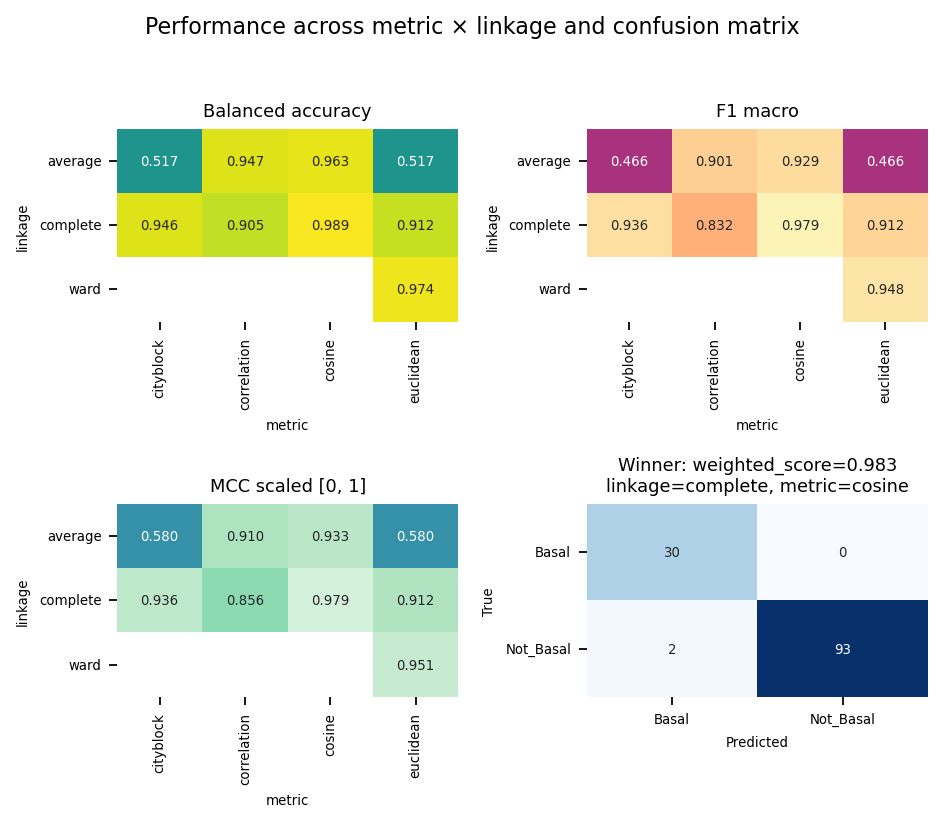

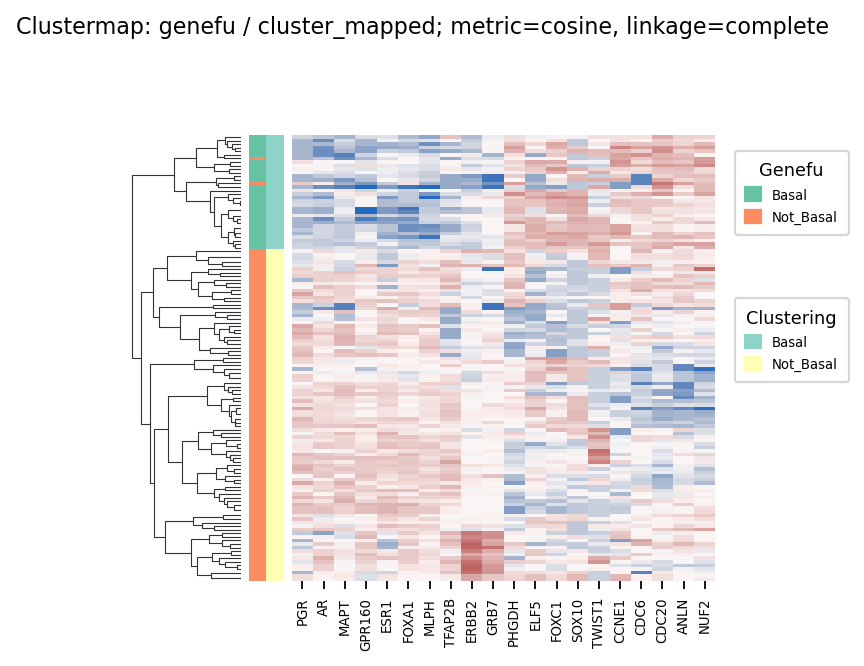


Top-3 combinations by general score:
 linkage    metric  balanced_accuracy  f1_macro  mcc_scaled  weighted_score
complete    cosine           0.989474  0.978552    0.979000        0.982509
    ward euclidean           0.973684  0.948025    0.950564        0.957767
 average    cosine           0.963158  0.928636    0.933321        0.942124


In [18]:
res_basal = cluster_breast_cancer_target_vs_rest(
    df_bg_genes_scaled=df_bg_genes_scaled,
    genes=sorted(basal_gene_set),
    y_subtype_genefu=y_subtype_genefu,
    target_label='Basal',
    metrics=metrics,
    linkages=linkages,
    plot=True
)

#### ERBB2+ vs rest

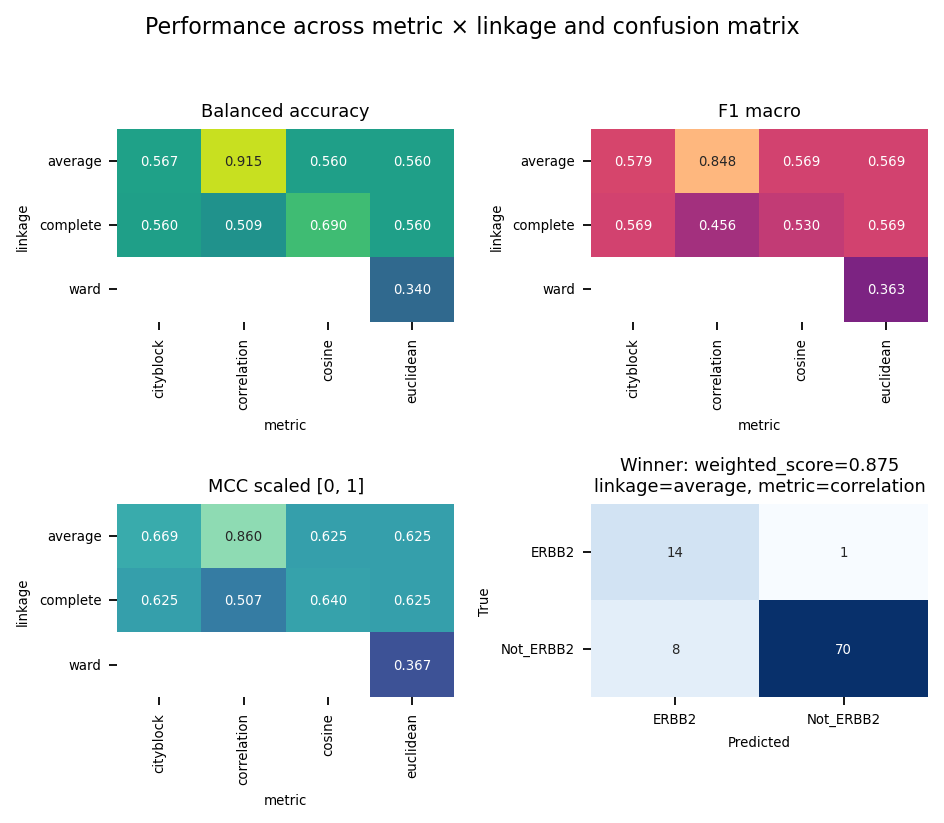

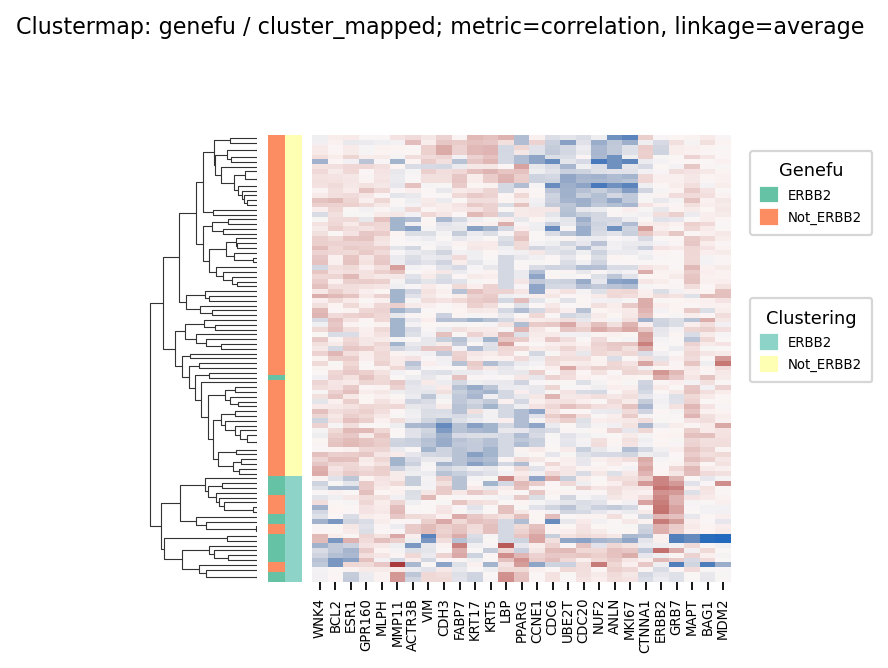


Top-3 combinations by general score:
 linkage      metric  balanced_accuracy  f1_macro  mcc_scaled  weighted_score
 average correlation           0.915385  0.848177    0.859503        0.875098
complete      cosine           0.689744  0.530303    0.640233        0.619086
 average   cityblock           0.566667  0.579186    0.669031        0.601758


In [19]:
res_erbb2 = cluster_breast_cancer_target_vs_rest(
    df_bg_genes_scaled=res_basal.df_cluster_neg,
    genes=sorted(erbb2_gene_set),
    y_subtype_genefu=res_basal.genefu_labels_for_non_target,
    target_label='ERBB2',
    metrics=metrics,
    linkages=linkages,
    plot=True,
)

#### LumB vs LumA

Here LumA is equal to Not_LumB.

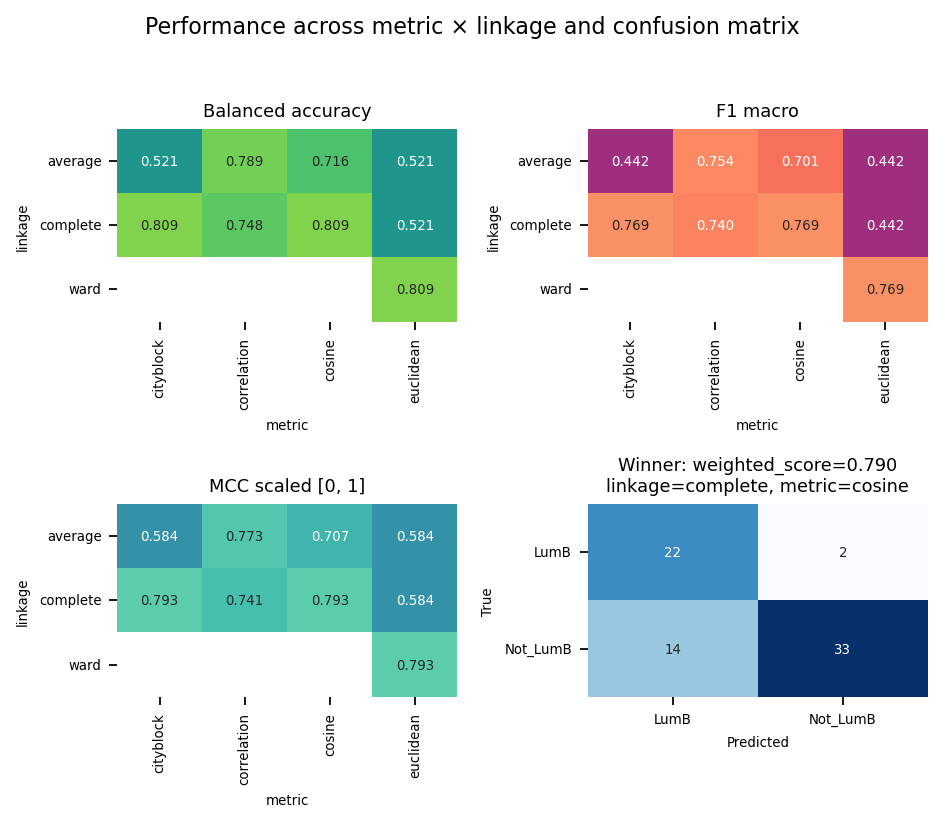

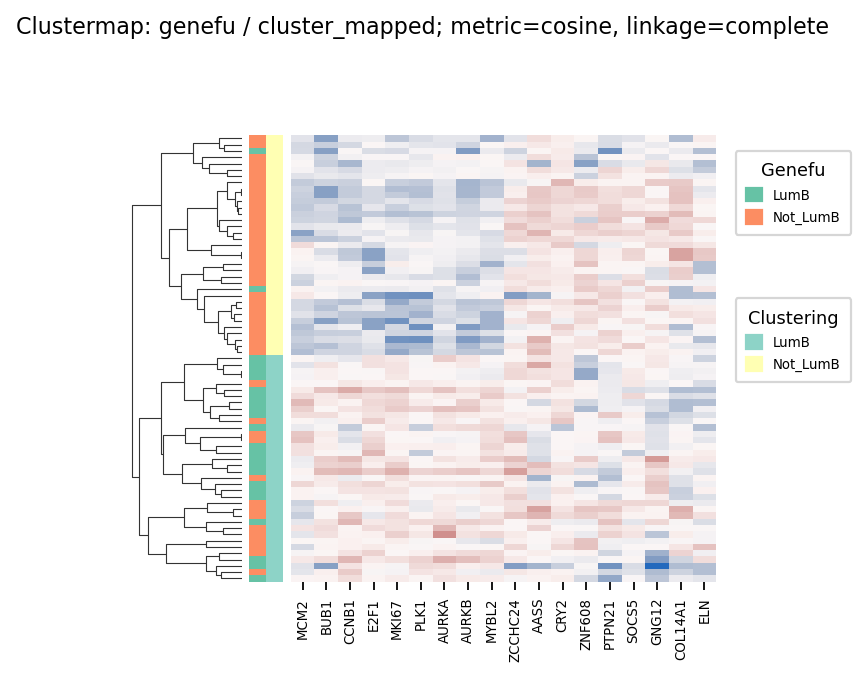


Top-3 combinations by general score:
 linkage    metric  balanced_accuracy  f1_macro  mcc_scaled  weighted_score
complete    cosine           0.809397  0.769106    0.792742        0.790299
complete cityblock           0.809397  0.769106    0.792742        0.790299
    ward euclidean           0.809397  0.769106    0.792742        0.790299


In [20]:
res_lum = cluster_breast_cancer_target_vs_rest(
    df_bg_genes_scaled=res_erbb2.df_cluster_neg,
    genes=sorted(luma_lumb_union_gene_set),
    y_subtype_genefu=res_erbb2.genefu_labels_for_non_target,
    target_label='LumB',
    metrics=metrics,
    linkages=linkages,
    plot=True,
)

The last split is the most challenging because LumA and LumB are biologically closer than Basal and ERBB2. At the same time, the heatmap suggests that agglomerative clustering separates these samples more clearly than `genefu`.

#### Final subtype labels

The three binary clustering steps are combined into a single four-class label set. Samples not assigned to LumB in the last step are labeled as LumA.

In [24]:
cluster_labels_result = res_basal.y_pred_mapped_best.copy()
cluster_labels_result.update(res_erbb2.y_pred_mapped_best)
cluster_labels_result.update(res_lum.y_pred_mapped_best)
cluster_labels_result = cluster_labels_result.replace('Not_LumB', 'LumA')

print(cluster_labels_result.value_counts())

LumB     36
LumA     35
Basal    32
ERBB2    22
Name: count, dtype: int64


Compare the final subtype distribution with `genefu` assignments:

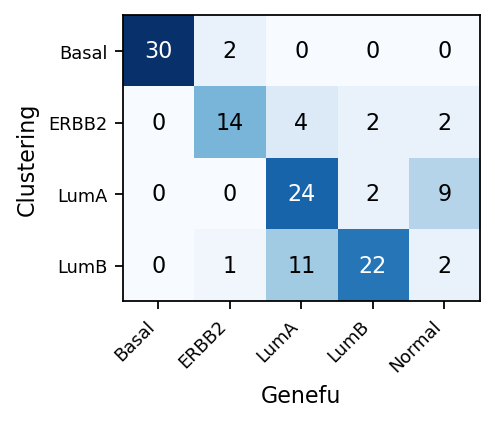

In [25]:
cm_df = pd.crosstab(
    pd.Series(cluster_labels_result, name='Clusters'),
    pd.Series(y_subtype_genefu, name='Genefu'),
).reindex(
    index=['Basal', 'ERBB2', 'LumA', 'LumB'],
    columns=['Basal', 'ERBB2', 'LumA', 'LumB', 'Normal'],
    fill_value=0,
)

fig, ax = plt.subplots(figsize=(3.2, 4), dpi=160)
ax.imshow(cm_df.to_numpy(), cmap='Blues')

ax.set_xticks(np.arange(cm_df.shape[1]))
ax.set_yticks(np.arange(cm_df.shape[0]))
ax.set_xticklabels(cm_df.columns, rotation=45, ha='right')
ax.set_yticklabels(cm_df.index)

ax.set_xlabel('Genefu', fontsize=10)
ax.set_ylabel('Clustering', fontsize=10)
ax.tick_params(axis='both', labelsize=8)

cm_plot = cm_df.to_numpy()
threshold = cm_plot.max() / 2

for i in range(cm_plot.shape[0]):
    for j in range(cm_plot.shape[1]):
        ax.text(
            j, i, cm_plot[i, j],
            ha='center', va='center',
            fontsize=10,
            color='white' if cm_plot[i, j] > threshold else 'black',
        )

plt.tight_layout()
plt.show()

## Save classification results

The final donor-level subtype labels are exported as a tab-separated table for downstream analysis.

In [26]:
cluster_labels_result.index = cluster_labels_result.index.str.replace('__malignant cell', '')
cluster_labels_result.to_csv('../data/PAM50_cluster_labels_result.tsv', sep='\t')